In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATASET_DIR = "dataset_split"
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.0005
WEIGHT_DECAY = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)


Kullanılan cihaz: cpu


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


In [4]:
train_ds = datasets.ImageFolder(DATASET_DIR + "/train", transform=train_transform)
val_ds   = datasets.ImageFolder(DATASET_DIR + "/val", transform=test_transform)
test_ds  = datasets.ImageFolder(DATASET_DIR + "/test", transform=test_transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_ds.classes)
print("Sınıf sayısı:", NUM_CLASSES)


Sınıf sayısı: 12


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = CNN().to(device)


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


In [7]:
print("Eğitim başlıyor...\n")

for epoch in range(EPOCHS):
    model.train()
    train_correct, train_total = 0, 0

    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Eğitim başlıyor...

Epoch 1/15 | Train Acc: 0.1656 | Val Acc: 0.2647
Epoch 2/15 | Train Acc: 0.2572 | Val Acc: 0.3471
Epoch 3/15 | Train Acc: 0.3563 | Val Acc: 0.4647
Epoch 4/15 | Train Acc: 0.4580 | Val Acc: 0.5941
Epoch 5/15 | Train Acc: 0.5345 | Val Acc: 0.6706
Epoch 6/15 | Train Acc: 0.5784 | Val Acc: 0.6059
Epoch 7/15 | Train Acc: 0.6587 | Val Acc: 0.7529
Epoch 8/15 | Train Acc: 0.7290 | Val Acc: 0.8412
Epoch 9/15 | Train Acc: 0.7227 | Val Acc: 0.8412
Epoch 10/15 | Train Acc: 0.7491 | Val Acc: 0.8706
Epoch 11/15 | Train Acc: 0.8005 | Val Acc: 0.9000
Epoch 12/15 | Train Acc: 0.8243 | Val Acc: 0.9059
Epoch 13/15 | Train Acc: 0.8118 | Val Acc: 0.9353
Epoch 14/15 | Train Acc: 0.8745 | Val Acc: 0.9059
Epoch 15/15 | Train Acc: 0.8632 | Val Acc: 0.9176


In [8]:
print("\nTest aşaması...\n")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_acc = np.mean(y_true == y_pred)
print(f"CNN Test Accuracy : {test_acc:.4f}")



Test aşaması...

CNN Test Accuracy : 0.9231


In [9]:
cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

f1_scores = []
for c in range(NUM_CLASSES):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0
    f1_scores.append(f1)

macro_f1 = np.mean(f1_scores)
print(f"CNN Test Macro F1 : {macro_f1:.4f}")


CNN Test Macro F1 : 0.9073


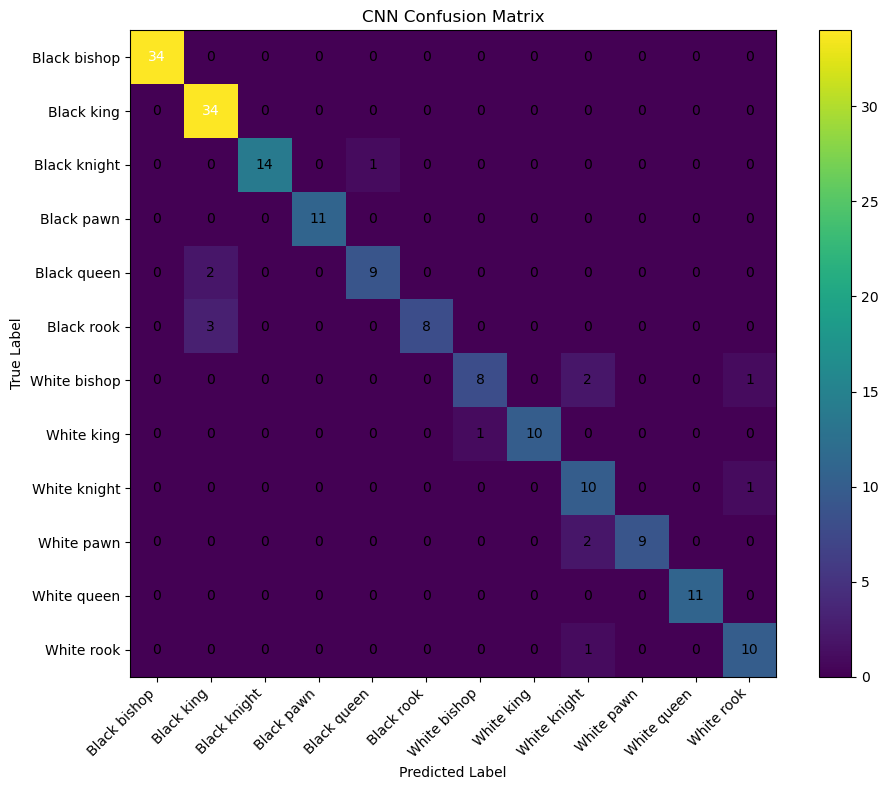

In [10]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.viridis)
plt.title("CNN Confusion Matrix")
plt.colorbar()

class_names = train_ds.classes
tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
